## Imports

In [1]:
import sys
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd().parents[0]))

import scripts.prepare as prepare
import scripts.services as services
import scripts.roi as roi_services
import scripts.bss_pipeline as bss_pl
import scripts.visualization as vis

from scipy.interpolate import make_interp_spline

%load_ext autoreload
%autoreload 2

### fixed variables

In [2]:
N_PC = 10 # discovered by analysis
NFRAMES_OUT = 1200
SCALE_OUT = 0.2
FPS_OUT = 240
N_PEAKS = 5
ROIS = roi_services.load_rois(str(Path.cwd().parents[0] / "rois/rois.json"))
BASE_DIR = (Path.cwd().parents[0] / "videos" / "camp_3")

### load video paths

In [8]:
p1_video_paths = services.get_video_paths(base_dir=BASE_DIR, start_date="25/05/2026", end_date="31/05/2026", plant_id=1, periods=("m"))
p2_video_paths = services.get_video_paths(base_dir=BASE_DIR, start_date="25/05/2026", end_date="31/05/2026", plant_id=2, periods=("m"))

### methodology

In [4]:
def apply_methodology(video_paths):
    results = []
    
    progress = tqdm(total=len(video_paths), desc="Processando vídeos", unit="vídeo")

    for VIDEO_PATH_IN in video_paths:
        VIDEO_NAME = VIDEO_PATH_IN.name
        
        progress.set_postfix_str(f"Processando: {VIDEO_NAME}")
            
        VIDEO_PATH_OUT = str(Path.cwd().parents[0] / "outputs/misc" / VIDEO_NAME)
        
        VIDEO_ROI = ROIS[VIDEO_NAME]
        
        prepare.pre_processing(VIDEO_PATH_IN, VIDEO_PATH_OUT, NFRAMES_OUT, FPS_OUT, SCALE_OUT, VIDEO_ROI)
        
        video_out_info = services.get_video_info(VIDEO_PATH_OUT)
        
        unmixed, winvmix, w, h = bss_pl.run_pipeline(VIDEO_PATH_OUT, N_PC)
        
        fft_data = bss_pl.compute_fft_for_components(unmixed, video_out_info["fps"], range(N_PC))
        peaks_info = bss_pl.get_highest_peak_frequencies(fft_data, N_PEAKS)
        
        amp, freq, source = services.get_dominant_source(peaks_info, frequency_threshold = 1.0)
        
        results.append({
            "date": VIDEO_PATH_IN.parent.parent.parent.name,
            "plant_id": VIDEO_PATH_IN.parent.parent.name.split("_")[-1],
            "period": VIDEO_PATH_IN.parent.name,
            "video": VIDEO_PATH_IN.name,
            "frequency": freq,
            "amplitude": amp,
            "source": source,
        })
        
        # Exibe o resultado parcial na barra
        progress.set_postfix({"freq": f"{freq:.2f} Hz", "amp": f"{amp:.2f}", "source": source})
        
        tqdm.write(f"{VIDEO_NAME} | plant={results[-1]['plant_id']} | period={results[-1]['period']} | freq={freq:.2f} Hz | amp={amp:.2f} | source={source}")
        
        # Avança explicitamente 1 vídeo
        progress.update(1)
    
    progress.close()  
    
    return results

In [9]:
p1_results = apply_methodology(p1_video_paths)
p2_results = apply_methodology(p2_video_paths)

Processando vídeos:   0%|          | 0/7 [00:00<?, ?vídeo/s]

VID_20260525_073740210.mp4 | plant=1 | period=m | freq=2.20 Hz | amp=197.77 | source=8
VID_20260526_073704629.mp4 | plant=1 | period=m | freq=2.40 Hz | amp=162.05 | source=5
VID_20260527_073900146.mp4 | plant=1 | period=m | freq=2.00 Hz | amp=92.39 | source=8
VID_20260528_060712313.mp4 | plant=1 | period=m | freq=2.00 Hz | amp=143.15 | source=9
VID_20260529_083217557.mp4 | plant=1 | period=m | freq=1.20 Hz | amp=138.25 | source=8
VID_20260530_074908974.mp4 | plant=1 | period=m | freq=2.20 Hz | amp=219.22 | source=8
VID_20260531_074058464.mp4 | plant=1 | period=m | freq=2.20 Hz | amp=138.56 | source=8


Processando vídeos:   0%|          | 0/7 [00:00<?, ?vídeo/s]

VID_20260525_073831392.mp4 | plant=2 | period=m | freq=2.00 Hz | amp=129.90 | source=9
VID_20260526_073755265.mp4 | plant=2 | period=m | freq=1.60 Hz | amp=231.64 | source=9
VID_20260527_074035158.mp4 | plant=2 | period=m | freq=1.40 Hz | amp=127.45 | source=8
VID_20260528_060627096.mp4 | plant=2 | period=m | freq=2.00 Hz | amp=181.20 | source=9
VID_20260529_083140178.mp4 | plant=2 | period=m | freq=1.60 Hz | amp=123.32 | source=9
VID_20260530_074702260.mp4 | plant=2 | period=m | freq=1.60 Hz | amp=118.94 | source=9
VID_20260531_074018077.mp4 | plant=2 | period=m | freq=1.80 Hz | amp=186.98 | source=7


### plots

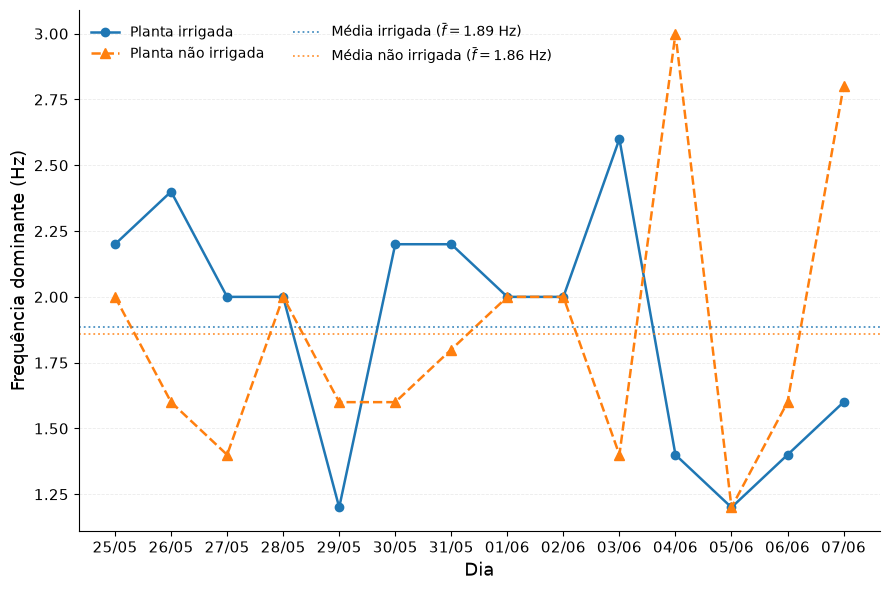

In [6]:
dias = [datetime.strptime(r["date"], "%Y%m%d").strftime("%d/%m") for r in p1_results]

planta_irrigada = [round(r["frequency"], 2) for r in p1_results]
planta_nao_irrigada = [round(r["frequency"], 2) for r in p2_results]

media_irrigada = np.mean(planta_irrigada)
media_nao_irrigada = np.mean(planta_nao_irrigada)

fig, ax = plt.subplots(figsize=(9, 6))

# Séries temporais
line1, = ax.plot(
    dias,
    planta_irrigada,
    marker="o",
    markersize=6,
    linewidth=1.8,
    label="Planta irrigada",
)

line2, = ax.plot(
    dias,
    planta_nao_irrigada,
    marker="^",
    markersize=7,
    linestyle="--",
    linewidth=1.8,
    label="Planta não irrigada",
)

# Médias
ax.axhline(
    media_irrigada,
    linestyle=":",
    linewidth=1.3,
    alpha=0.8,
    color=line1.get_color(),
    label=rf"Média irrigada ($\bar{{f}}={media_irrigada:.2f}$ Hz)",
)

ax.axhline(
    media_nao_irrigada,
    linestyle=":",
    linewidth=1.3,
    alpha=0.8,
    color=line2.get_color(),
    label=rf"Média não irrigada ($\bar{{f}}={media_nao_irrigada:.2f}$ Hz)",
)

# Eixos
ax.set_xlabel("Dia", fontsize=13)
ax.set_ylabel("Frequência dominante (Hz)", fontsize=13)

ax.tick_params(axis="both", labelsize=11)

# Grade discreta apenas no eixo y
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.25,
)

# Remove bordas superior e direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legenda
ax.legend(
    fontsize=10,
    frameon=False,
    ncol=2,
)

fig.tight_layout()

fig.savefig(
    "frequencias_plantas_2.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()